## Predictive grid cell main

In this notebook, we train path integrating RNNs on different types of trajectories to better understand the role predictive grid cells may play in the computations underlying the RNN.

To do this, we do the following steps:
1. Define the RNN model
2. Define place cells
2. Define the trajectory generator
3. Define the trainer
4. Train the RNN and save intermediate outputs

### Loading globals

In [54]:
import os
os.chdir("/Users/wredman/Documents/GitHub/predictive-grid-cell-analysis/")

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import argparse
import torch.cuda

### Step 1: Define RNN model

Here we define the RNN model that will be trained on path integration

In [56]:
class RNN(torch.nn.Module):
    def __init__(self, options, place_cells):
        super(RNN, self).__init__()
        self.Ng = options.Ng
        self.Np = options.Np
        self.velocity_dim = getattr(options, 'velocity_dim', 2)
        self.sequence_length = options.sequence_length
        self.weight_decay = options.weight_decay
        self.place_cells = place_cells

        # Input weights
        self.encoder = torch.nn.Linear(self.Np, self.Ng, bias=False)
        self.RNN = torch.nn.RNN(input_size=self.velocity_dim,
                                hidden_size=self.Ng,
                                nonlinearity=options.activation,
                                bias=False)
        # Linear read-out weights
        self.decoder = torch.nn.Linear(self.Ng, self.Np, bias=False)

        self.softmax = torch.nn.Softmax(dim=-1)

    def g(self, inputs):
        """
        Compute grid cell activations.
        Args:
            inputs: Tuple (v, p0) where v has shape [batch_size, sequence_length, velocity_dim].

        Returns:
            g: Batch of grid cell activations with shape [batch_size, sequence_length, Ng].
        """
        v, p0 = inputs
        init_state = self.encoder(p0)[None]
        g,_ = self.RNN(v, init_state)
        return g

    def predict(self, inputs):
        """
        Predict place cell code.
        Args:
            inputs: Tuple (v, p0) where v has shape [batch_size, sequence_length, velocity_dim].

        Returns:
            place_preds: Predicted place cell activations with shape
                [batch_size, sequence_length, Np].
        """
        place_preds = self.decoder(self.g(inputs))

        return place_preds

    def compute_loss(self, inputs, pc_outputs, pos):
        """
        Compute avg. loss and decoding error.
        Args:
            inputs: Tuple (v, p0) where v has shape [batch_size, sequence_length, velocity_dim].
            pc_outputs: Ground truth place cell activations with shape
                [batch_size, sequence_length, Np].
            pos: Ground truth 2d position with shape [batch_size, sequence_length, 2].

        Returns:
            loss: Avg. loss for this training batch.
            err: Avg. decoded position error in cm.
        """
        y = pc_outputs
        preds = self.predict(inputs)
        yhat = self.softmax(self.predict(inputs))
        loss = -(y*torch.log(yhat)).sum(-1).mean()

        # Weight regularization
        loss += self.weight_decay * (self.RNN.weight_hh_l0**2).sum()

        # Compute decoding error
        pred_pos = self.place_cells.get_nearest_cell_pos(preds)
        err = torch.sqrt(((pos - pred_pos)**2).sum(-1)).mean()

        return loss, err


### Step 2: Define place cells

Now, we define the place cell activations, which act as the target output for the loss.

In [57]:
class PlaceCells(object):

    def __init__(self, options, us=None):
        self.Np = options.Np
        self.sigma = options.place_cell_rf
        self.surround_scale = options.surround_scale
        self.box_width = options.box_width
        self.box_height = options.box_height
        self.is_periodic = options.periodic
        self.DoG = options.DoG
        self.device = options.device
        self.softmax = torch.nn.Softmax(dim=-1)

        # Randomly tile place cell centers across environment
        np.random.seed(0)
        usx = np.random.uniform(-self.box_width/2, self.box_width/2, (self.Np,))
        usy = np.random.uniform(-self.box_width/2, self.box_width/2, (self.Np,))
        self.us = torch.tensor(np.vstack([usx, usy]).T)
        # If using a GPU, put on GPU
        self.us = self.us.to(self.device)
        # self.us = torch.tensor(np.load('models/example_pc_centers.npy')).cuda()

    def get_activation(self, pos):
        '''
        Get place cell activations for a given position.

        Args:
            pos: 2d position of shape [batch_size, sequence_length, 2].

        Returns:
            outputs: Place cell activations with shape [batch_size, sequence_length, Np].
        '''
        d = torch.abs(pos[:, :, None, :] - self.us[None, None, ...]).float()

        if self.is_periodic:
            dx = d[:,:,:,0]
            dy = d[:,:,:,1]
            dx = torch.minimum(dx, self.box_width - dx)
            dy = torch.minimum(dy, self.box_height - dy)
            d = torch.stack([dx,dy], axis=-1)

        norm2 = (d**2).sum(-1)

        # Normalize place cell outputs with prefactor alpha=1/2/np.pi/self.sigma**2,
        # or, simply normalize with softmax, which yields same normalization on
        # average and seems to speed up training.
        outputs = self.softmax(-norm2/(2*self.sigma**2))

        if self.DoG:
            # Again, normalize with prefactor
            # beta=1/2/np.pi/self.sigma**2/self.surround_scale, or use softmax.
            outputs -= self.softmax(-norm2/(2*self.surround_scale*self.sigma**2))

            # Shift and scale outputs so that they lie in [0,1].
            min_output,_ = outputs.min(-1,keepdims=True)
            outputs += torch.abs(min_output)
            outputs /= outputs.sum(-1, keepdims=True)
        return outputs

    def get_nearest_cell_pos(self, activation, k=3):
        '''
        Decode position using centers of k maximally active place cells.

        Args:
            activation: Place cell activations of shape [batch_size, sequence_length, Np].
            k: Number of maximally active place cells with which to decode position.

        Returns:
            pred_pos: Predicted 2d position with shape [batch_size, sequence_length, 2].
        '''
        _, idxs = torch.topk(activation, k=k)
        pred_pos = self.us[idxs].mean(-2)
        return pred_pos

    def grid_pc(self, pc_outputs, res=32):
        ''' Interpolate place cell outputs onto a grid'''
        coordsx = np.linspace(-self.box_width/2, self.box_width/2, res)
        coordsy = np.linspace(-self.box_height/2, self.box_height/2, res)
        grid_x, grid_y = np.meshgrid(coordsx, coordsy)
        grid = np.stack([grid_x.ravel(), grid_y.ravel()]).T

        # Convert to numpy
        pc_outputs = pc_outputs.reshape(-1, self.Np)

        T = pc_outputs.shape[0] #T vs transpose? What is T? (dim's?)
        pc = np.zeros([T, res, res])
        for i in range(len(pc_outputs)):
            gridval = scipy.interpolate.griddata(self.us.cpu(), pc_outputs[i], grid)
            pc[i] = gridval.reshape([res, res])

        return pc

### Step 3: Define the trajectory generator

Next, we define the kinds of trajectories that are sampled by the RNN agent.

In [58]:
class TrajectoryGenerator(object):

    def __init__(self, options, place_cells):
        self.options = options
        self.place_cells = place_cells

    def avoid_wall(self, position, hd, box_width, box_height):
        '''
        Compute distance and angle to nearest wall
        '''
        x = position[:, 0]
        y = position[:, 1]
        dists = [box_width / 2 - x, box_height / 2 - y, box_width / 2 + x, box_height / 2 + y]
        d_wall = np.min(dists, axis=0)
        angles = np.arange(4) * np.pi / 2
        theta = angles[np.argmin(dists, axis=0)]
        hd = np.mod(hd, 2 * np.pi)
        a_wall = hd - theta
        a_wall = np.mod(a_wall + np.pi, 2 * np.pi) - np.pi

        is_near_wall = (d_wall < self.border_region) * (np.abs(a_wall) < np.pi / 2)
        turn_angle = np.zeros_like(hd)
        turn_angle[is_near_wall] = np.sign(a_wall[is_near_wall]) * (np.pi / 2 - np.abs(a_wall[is_near_wall]))

        return is_near_wall, turn_angle

    def generate_trajectory(self, box_width, box_height, batch_size):
        '''Generate a walk in a rectangular box'''
        # Set/load in variables describing properties of trajectories to sample
        samples = self.options.sequence_length
        dt = getattr(self.options, "trajectory_dt", 0.02)  # seconds
        turn_sigma_scale = getattr(self.options, "trajectory_turn_sigma_scale", 1.0)
        sigma = 5.76 * 2 * turn_sigma_scale  # stdev rotation velocity (rads/sec)
        b = 0.13 * 2 * np.pi  # forward velocity rayleigh dist scale (m/sec)
        speed_scale = getattr(self.options, "trajectory_speed_scale", 1.0)
        speed_cap = getattr(self.options, "trajectory_speed_max", None)
        if speed_cap is not None:
            speed_cap = max(0.0, float(speed_cap))
        velocity_smoothing = float(np.clip(getattr(self.options, "trajectory_velocity_smoothing", 0.0), 0.0, 0.999))
        mu = 0  # turn angle bias
        self.border_region = getattr(self.options, "trajectory_border_region", 0.03)  # meters
        wall_slowdown = getattr(self.options, "trajectory_wall_slowdown", 0.25)
        wall_turn_scale = getattr(self.options, "trajectory_wall_turn_scale", 1.0)
        traj_style = str(getattr(self.options, "trajectory_style", "random_walk")).lower()
        if traj_style not in {"random_walk", "straight", "per_step_random"}:
            traj_style = "random_walk"
        fixed_speed = getattr(self.options, "trajectory_fixed_speed", None)
        if fixed_speed is not None:
            fixed_speed = float(fixed_speed)

        # Initialize variables
        position = np.zeros([batch_size, samples + 2, 2])
        head_dir = np.zeros([batch_size, samples + 2])
        position[:, 0, 0] = np.random.uniform(-box_width / 2, box_width / 2, batch_size)
        position[:, 0, 1] = np.random.uniform(-box_height / 2, box_height / 2, batch_size)
        head_dir[:, 0] = np.random.uniform(0, 2 * np.pi, batch_size)
        velocity = np.zeros([batch_size, samples + 2])

        # Generate sequence of random boosts and turns
        random_turn = np.random.normal(mu, sigma, [batch_size, samples + 1])
        random_vel = np.random.rayleigh(b, [batch_size, samples + 1]) * speed_scale
        if traj_style == "straight" and fixed_speed is not None:
            random_vel[:] = fixed_speed
            random_turn[:] = 0.0
        v = np.abs(np.random.normal(0, b * np.pi / 2, batch_size)) * speed_scale

        for t in range(samples + 1):
            if traj_style == "per_step_random":
                # Re-sample heading every step for maximally unpredictable motion
                head_dir[:, t] = np.random.uniform(-np.pi, np.pi, batch_size)

            # Update velocity
            target_v = random_vel[:, t]
            if velocity_smoothing > 0:
                v = velocity_smoothing * v + (1 - velocity_smoothing) * target_v
            else:
                v = target_v
            if speed_cap is not None:
                v = np.minimum(v, speed_cap)
            turn_angle = np.zeros(batch_size)

            if not self.options.periodic:
                # If in border region, turn and slow down
                is_near_wall, avoid_turn = self.avoid_wall(position[:, t], head_dir[:, t], box_width, box_height)
                avoid_turn *= wall_turn_scale
                turn_angle += avoid_turn
                v[is_near_wall] *= wall_slowdown

            # Update turn angle
            if traj_style == "straight":
                # Keep heading fixed except for wall avoidance
                turn_angle += 0.0
            elif traj_style == "per_step_random":
                # Heading already resampled; only apply wall avoidance
                turn_angle += 0.0
            else:
                turn_angle += dt * random_turn[:, t]

            # Take a step
            velocity[:, t] = v * dt
            update = velocity[:, t, None] * np.stack([np.cos(head_dir[:, t]), np.sin(head_dir[:, t])], axis=-1)
            position[:, t + 1] = position[:, t] + update

            # Rotate head direction
            if traj_style == "per_step_random":
                head_dir[:, t + 1] = np.random.uniform(-np.pi, np.pi, batch_size)
            else:
                head_dir[:, t + 1] = head_dir[:, t] + turn_angle

        # Periodic boundaries
        if self.options.periodic:
            position[:, :, 0] = np.mod(position[:, :, 0] + box_width / 2, box_width) - box_width / 2
            position[:, :, 1] = np.mod(position[:, :, 1] + box_height / 2, box_height) - box_height / 2

        head_dir = np.mod(head_dir + np.pi, 2 * np.pi) - np.pi  # Periodic variable

        traj = {}
        # Input variables
        traj['init_hd'] = head_dir[:, 0, None]
        traj['init_x'] = position[:, 1, 0, None]
        traj['init_y'] = position[:, 1, 1, None]

        traj['ego_v'] = velocity[:, 1:-1]
        ang_v = np.diff(head_dir, axis=-1)
        traj['phi_x'], traj['phi_y'] = np.cos(ang_v)[:, :-1], np.sin(ang_v)[:, :-1]

        # Target variables
        traj['target_hd'] = head_dir[:, 1:-1]
        traj['target_x'] = position[:, 2:, 0]
        traj['target_y'] = position[:, 2:, 1]

        return traj

    def get_generator(self, batch_size=None, box_width=None, box_height=None):
        '''
        Returns a generator that yields batches of trajectories
        '''
        if not batch_size:
            batch_size = self.options.batch_size
        if not box_width:
            box_width = self.options.box_width
        if not box_height:
            box_height = self.options.box_height

        while True:
            traj = self.generate_trajectory(box_width, box_height, batch_size)

            v = np.stack([traj['ego_v'] * np.cos(traj['target_hd']),
                          traj['ego_v'] * np.sin(traj['target_hd'])], axis=-1)
            v = torch.tensor(v, dtype=torch.float32).transpose(0, 1)

            pos = np.stack([traj['target_x'], traj['target_y']], axis=-1)
            pos = torch.tensor(pos, dtype=torch.float32).transpose(0, 1)
            # Put on GPU if GPU is available
            pos = pos.to(self.options.device)
            place_outputs = self.place_cells.get_activation(pos)

            init_pos = np.stack([traj['init_x'], traj['init_y']], axis=-1)
            init_pos = torch.tensor(init_pos, dtype=torch.float32)
            init_pos = init_pos.to(self.options.device)
            init_actv = self.place_cells.get_activation(init_pos).squeeze()

            v = v.to(self.options.device)
            inputs = (v, init_actv)

            yield (inputs, place_outputs, pos)

    def get_test_batch(self, batch_size=None, box_width=None, box_height=None):
        ''' For testing performance, returns a batch of smample trajectories'''
        if not batch_size:
            batch_size = self.options.batch_size
        if not box_width:
            box_width = self.options.box_width
        if not box_height:
            box_height = self.options.box_height

        traj = self.generate_trajectory(box_width, box_height, batch_size)

        v = np.stack([traj['ego_v'] * np.cos(traj['target_hd']),
                      traj['ego_v'] * np.sin(traj['target_hd'])], axis=-1)
        v = torch.tensor(v, dtype=torch.float32).transpose(0, 1)

        pos = np.stack([traj['target_x'], traj['target_y']], axis=-1)
        pos = torch.tensor(pos, dtype=torch.float32).transpose(0, 1)
        pos = pos.to(self.options.device)
        place_outputs = self.place_cells.get_activation(pos)

        init_pos = np.stack([traj['init_x'], traj['init_y']], axis=-1)
        init_pos = torch.tensor(init_pos, dtype=torch.float32)
        init_pos = init_pos.to(self.options.device)
        init_actv = self.place_cells.get_activation(init_pos).squeeze()

        v = v.to(self.options.device)
        inputs = (v, init_actv)

        return (inputs, pos, place_outputs)


### Step 4: Define the trainer

Finally, we define the trainer which coordinates sampling trajectories, evaluating the RNN model's performance, and updating the RNN model parameters.

In [59]:
 class Trainer(object):
    def __init__(self, options, model, trajectory_generator, restore=True):
        self.options = options
        self.model = model
        self.trajectory_generator = trajectory_generator
        lr = self.options.learning_rate
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.loss = []
        self.err = []
        self.history: Dict[str, List[float]] = {"epoch": [], "loss": [], "err": []}
        self.grid_history: List[Dict[str, Any]] = []

        # Set up checkpoints
        self.ckpt_dir = os.path.join(options.save_dir, options.run_ID)
        ckpt_path = os.path.join(self.ckpt_dir, 'most_recent_model.pth')
        if restore and os.path.isdir(self.ckpt_dir) and os.path.isfile(ckpt_path):
            self.model.load_state_dict(torch.load(ckpt_path))
            print("Restored trained model from {}".format(ckpt_path))
        else:
            if not os.path.isdir(self.ckpt_dir):
                os.makedirs(self.ckpt_dir, exist_ok=True)
            print("Initializing new model from scratch.")
            print("Saving to: {}".format(self.ckpt_dir))
        self.metrics_path = os.path.join(self.ckpt_dir, "training_metrics.json")
        self.metrics_plot_path = os.path.join(self.ckpt_dir, "training_curves.png")

    def train_step(self, inputs, pc_outputs, pos):
        '''
        Train on one batch of trajectories.

        Args:
            inputs: Batch of 2d velocity inputs with shape [batch_size, sequence_length, 2].
            pc_outputs: Ground truth place cell activations with shape
                [batch_size, sequence_length, Np].
            pos: Ground truth 2d position with shape [batch_size, sequence_length, 2].

        Returns:
            loss: Avg. loss for this training batch.
            err: Avg. decoded position error in cm.
        '''
        self.model.zero_grad()

        loss, err = self.model.compute_loss(inputs, pc_outputs, pos)

        loss.backward()
        self.optimizer.step()

        return loss.item(), err.item()

    def train(self, n_epochs: int = 1000, n_steps=10, save=True):
        '''
        Train model on simulated trajectories.

        Args:
            n_steps: Number of training steps
            save: If true, save a checkpoint after each epoch.
        '''

        # Construct generator
        gen = self.trajectory_generator.get_generator()

        # tbar = tqdm(range(n_steps), leave=False)
        for epoch_idx in range(n_epochs):
            epoch_losses: List[float] = []
            epoch_errs: List[float] = []
            for step_idx in range(n_steps):
                inputs, pc_outputs, pos = next(gen)
                loss, err = self.train_step(inputs, pc_outputs, pos)
                self.loss.append(loss)
                self.err.append(err)
                epoch_losses.append(loss)
                epoch_errs.append(err)

                # Log error rate to progress bar
                # tbar.set_description('Error = ' + str(np.int(100*err)) + 'cm')

                print('Epoch: {}/{}. Step {}/{}. Loss: {}. Err: {}cm'.format(
                    epoch_idx, n_epochs, step_idx, n_steps,
                    np.round(loss, 2), np.round(100 * err, 2)))

                if step_idx == 0:
                    print(np.shape(pos))
                    plt.figure()
                    for nn in range(options.batch_size):
                        plt.plot(pos[:, nn, 0], pos[:, nn, 1], 'b-')
                    plt.xlim([-options.box_width/2, options.box_width/2])
                    plt.ylim([-options.box_height/2, options.box_height/2])
                    plt.show()

            mean_loss = float(np.mean(epoch_losses))
            mean_err = float(np.mean(epoch_errs))
            self.history["epoch"].append(epoch_idx)
            self.history["loss"].append(mean_loss)
            self.history["err"].append(mean_err)
            self._save_metrics_file()
            self._plot_training_curves()

            if save:
                # Save checkpoint
                ckpt_path = os.path.join(self.ckpt_dir, 'epoch_{}.pth'.format(epoch_idx))
                torch.save(self.model.state_dict(), ckpt_path)
                torch.save(self.model.state_dict(), os.path.join(self.ckpt_dir,
                                                                 'most_recent_model.pth'))

                # Save a picture of rate maps
                save_ratemaps(self.model, self.trajectory_generator,
                              self.options, step=epoch_idx)


### Step 5: Train the RNN and save intermediate outputs

With all them pieces in place, we can now train the RNN!

In [62]:
def generate_run_ID(options):
    '''
    Create a unique run ID from the most relevant
    parameters. Remaining parameters can be found in
    params.npy file.
    '''
    params = [
        'steps', str(options.sequence_length),
        'batch', str(options.batch_size),
        'Ng', str(options.Ng),
        options.activation,
        'lr', str(options.learning_rate),
        'weight_decay', str(options.weight_decay),
        'shape', str(options.box_width) + "x" + str(options.box_height),
        'straightness', str(options.trajectory_turn_sigma_scale),
        'trajectory_style', str(options.trajectory_style),

        ]
    separator = '_'
    run_ID = separator.join(params)
    run_ID = run_ID.replace('.', '')

    return run_ID

In [63]:
class Args(argparse.Namespace):
    save_dir = '/Users/wredman/Documents/GitHub/Models/'
    n_epochs = 100
    n_steps = 1000
    batch_size = 200
    sequence_length = 20
    learning_rate = 1e-4
    Np = 512
    Ng = 4096
    place_cell_rf = 0.12
    surround_scale = 2
    activation = 'relu'
    weight_decay = 1e-4
    DoG = True
    box_width = 2.2
    box_height = 2.2
    periodic = False
    device = 'cpu' #'cuda'
    trajectory_style = 'straight'
    trajectory_fixed_speed = None
    trajectory_dt = 0.02
    trajectory_turn_sigma_scale = 1.0
    trajectory_speed_scale = 1.0
    trajectory_speed_max = None
    trajectory_velocity_smooth = 0.0
    trajectory_border_region = 0.03
    trajectory_wall_slowdown = 0.25
    trajectory_wall_turn_scale = 1.0

options=Args()
options.run_ID = generate_run_ID(options)

In [64]:
place_cells = PlaceCells(options)
model = RNN(options, place_cells)
model = model.to(options.device)
trajectory_generator = TrajectoryGenerator(options, place_cells)
trainer = Trainer(options, model, trajectory_generator)

Initializing new model from scratch.
Saving to: /Users/wredman/Documents/GitHub/Models/steps_20_batch_200_Ng_4096_relu_lr_00001_weight_decay_00001_shape_22x22_straightness_10_trajectory_style_straight


Epoch: 0/100. Step 0/1000. Loss: 6.37. Err: 97.84cm
torch.Size([20, 200, 2])


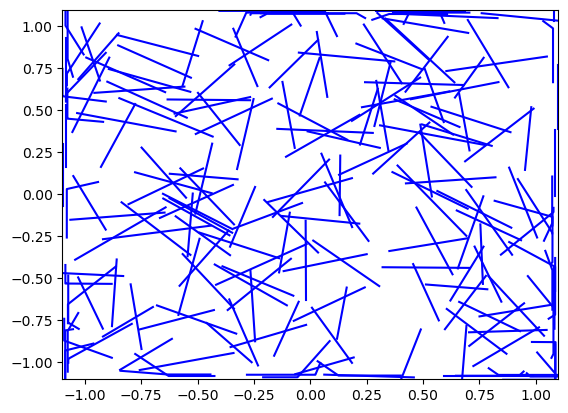

Epoch: 0/100. Step 1/1000. Loss: 6.37. Err: 92.81cm
Epoch: 0/100. Step 2/1000. Loss: 6.37. Err: 93.87cm
Epoch: 0/100. Step 3/1000. Loss: 6.37. Err: 88.7cm
Epoch: 0/100. Step 4/1000. Loss: 6.36. Err: 96.08cm
Epoch: 0/100. Step 5/1000. Loss: 6.36. Err: 96.61cm
Epoch: 0/100. Step 6/1000. Loss: 6.36. Err: 88.05cm
Epoch: 0/100. Step 7/1000. Loss: 6.36. Err: 93.57cm
Epoch: 0/100. Step 8/1000. Loss: 6.36. Err: 93.65cm
Epoch: 0/100. Step 9/1000. Loss: 6.35. Err: 94.09cm
Epoch: 0/100. Step 10/1000. Loss: 6.35. Err: 91.73cm
Epoch: 0/100. Step 11/1000. Loss: 6.35. Err: 91.43cm
Epoch: 0/100. Step 12/1000. Loss: 6.35. Err: 94.45cm
Epoch: 0/100. Step 13/1000. Loss: 6.34. Err: 94.43cm
Epoch: 0/100. Step 14/1000. Loss: 6.34. Err: 95.52cm
Epoch: 0/100. Step 15/1000. Loss: 6.34. Err: 98.37cm
Epoch: 0/100. Step 16/1000. Loss: 6.34. Err: 99.95cm
Epoch: 0/100. Step 17/1000. Loss: 6.34. Err: 93.44cm
Epoch: 0/100. Step 18/1000. Loss: 6.33. Err: 95.28cm
Epoch: 0/100. Step 19/1000. Loss: 6.33. Err: 95.57cm
Epo

KeyboardInterrupt: 

In [65]:
trainer.train(n_epochs=options.n_epochs, n_steps=options.n_steps)